
# Convergence Visualization
This notebook focuses on **how the algorithm converges**:

1. **Inner loop (Value Iteration)** — track the max-norm difference \(\|V^{(n+1)}-V^{(n)}\|_\infty\) over iterations.
2. **Outer loop (EM)** — track the observed-data log-likelihood and average prior share per EM iteration.


In [1]:

# %pip -q install numpy pandas scipy matplotlib

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from nfxp_model_v2 import NFXPFinLitConsBudgetAgeType, SpecType
from estimate_em_obs_v2 import load_data, prep_grids, build_features, per_id_loglike_for_type


## Paths & setup

In [2]:

CSV = "toy_panel_with_random_x.csv"
df = load_data(CSV)
a_grid, age_grid, x_grid, s_grid, y_bar = prep_grids(df, n_a=24)
model = NFXPFinLitConsBudgetAgeType(a_grid, age_grid, y_bar, x_grid, s_grid, gh_order=5)

# Demo spec for inner-loop tracing
spec_demo = SpecType(beta=0.95, sigma=2.0, R_f=1.02,
                     mu_lnR=np.log(1.06), sigma_lnR=0.20,
                     gamma0=1.0, gamma1=-0.01, delta0=-1.0, delta1=0.01)


## 1) Inner-loop (Value Iteration) convergence

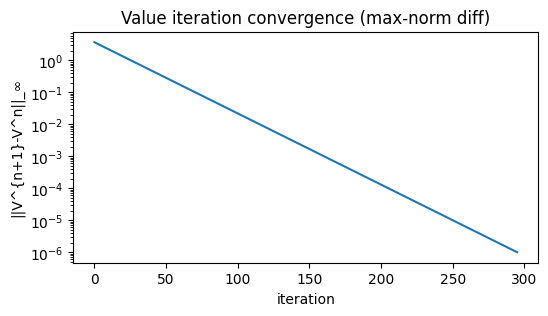

Iterations: 296  final diff: 9.944393610794577e-07


In [3]:

def value_iteration_with_trace(model, spec, max_iter=400, tol=1e-6):
    V = np.zeros((model.NA, model.NG))
    diffs = []
    for it in range(max_iter):
        V_new = np.empty_like(V)
        Q = np.zeros((model.NA, model.NG, model.NX, model.NS))
        for gi, g in enumerate(model.agegrid):
            next_gi = min(gi + 1, model.NG - 1)
            for ai, a in enumerate(model.agrid):
                for xi, x in enumerate(model.xgrid):
                    exp_vals_s = np.zeros(model.NS)
                    for k, w in enumerate(model.z_w):
                        Rk = np.exp(spec.mu_lnR + spec.sigma_lnR * model.z_nodes[k])
                        for si, s in enumerate(model.sgrid):
                            gross = a * (x * Rk + (1.0 - x) * spec.R_f) + model.y_bar
                            if x > 1e-12:
                                kfix = np.exp(spec.gamma0 + spec.gamma1 * g)
                                tau  = 0.9 / (1.0 + np.exp(-(spec.delta0 + spec.delta1 * g)))
                                res = (1.0 - tau) * gross - kfix
                            else:
                                res = gross
                            res = max(res, 1e-12)
                            c = (1.0 - s) * res
                            a_next = s * res
                            aj = int(np.argmin(np.abs(model.agrid - a_next)))
                            cont = V[aj, next_gi]
                            if abs(spec.sigma - 1.0) < 1e-12:
                                u = np.log(max(c, 1e-12))
                            else:
                                u = (max(c, 1e-12)**(1.0 - spec.sigma) - 1.0) / (1.0 - spec.sigma)
                            exp_vals_s[si] += w * (u + spec.beta * cont)
                    Q[ai, gi, xi, :] = exp_vals_s
                m = np.max(Q[ai, gi, :, :])
                V_new[ai, gi] = m + np.log(np.sum(np.exp(Q[ai, gi, :, :] - m)))
        diff = np.max(np.abs(V_new - V))
        diffs.append(diff)
        V = V_new
        if diff < tol:
            break
    return V, diffs

V_trace, diffs = value_iteration_with_trace(model, spec_demo, max_iter=400, tol=1e-6)

plt.figure(figsize=(6,3))
plt.semilogy(diffs)
plt.title("Value iteration convergence (max-norm diff)")
plt.xlabel("iteration")
plt.ylabel("||V^{n+1}-V^n||_∞")
plt.show()

print("Iterations:", len(diffs), " final diff:", diffs[-1])


## 2) Outer-loop (EM) convergence

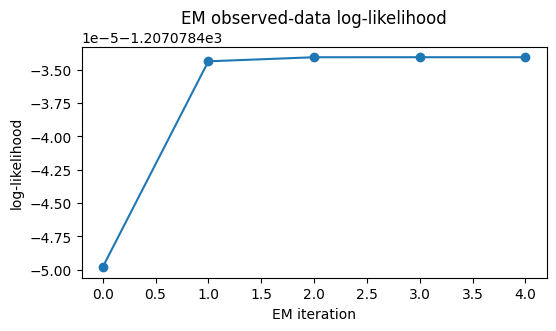

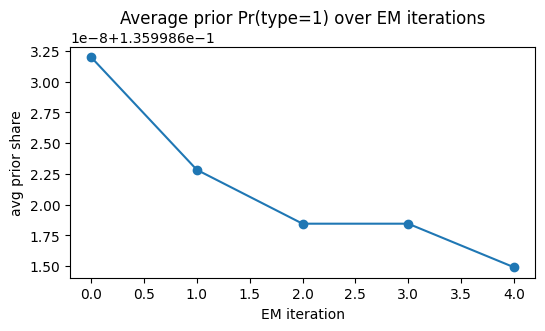

In [4]:

from scipy.optimize import minimize

def logistic(z): return 1.0/(1.0+np.exp(-z))

def run_em_with_trace(csv_path, n_a=24, gh_order=5, em_iters=6, nm_steps=30, seed=123):
    df = load_data(csv_path)
    a_grid, age_grid, x_grid, s_grid, y_bar = prep_grids(df, n_a=n_a)
    model = NFXPFinLitConsBudgetAgeType(a_grid, age_grid, y_bar, x_grid, s_grid, gh_order=gh_order)

    Zdf = build_features(df)
    ids = Zdf.index.to_numpy()
    Z = Zdf.to_numpy()
    id_to = {pid:i for i,pid in enumerate(ids)}

    beta_sigma_raw = np.array([0.0, 0.0])
    theta1 = np.array([ 1.0, -0.01, -1.0, 0.01])
    theta2 = np.array([ 2.0,  0.01, -2.0, 0.02])
    rng = np.random.default_rng(seed)
    eta = rng.normal(0.0, 0.1, size=Z.shape[1])

    base_const = dict(R_f=1.02, mu_lnR=np.log(1.06), sigma_lnR=0.20)
    def pack(bs):
        beta  = 0.50 + 0.49 * (1.0/(1.0+np.exp(-bs[0])))
        sigma = 0.50 + 4.50 * (1.0/(1.0+np.exp(-bs[1])))
        return beta, sigma

    hist = {"obs_ll": [], "avg_prior": []}

    for em in range(em_iters):
        beta, sigma = pack(beta_sigma_raw)
        spec1 = SpecType(beta=beta, sigma=sigma, **base_const,
                         gamma0=theta1[0], gamma1=theta1[1], delta0=theta1[2], delta1=theta1[3])
        spec2 = SpecType(beta=beta, sigma=sigma, **base_const,
                         gamma0=theta2[0], gamma1=theta2[1], delta0=theta2[2], delta1=theta2[3])

        _, CCP1, _, _ = model.value_iteration_one_type(spec1)
        _, CCP2, _, _ = model.value_iteration_one_type(spec2)

        ell1_vec, id_order1 = per_id_loglike_for_type(df, model, CCP1)
        ell2_vec, id_order2 = per_id_loglike_for_type(df, model, CCP2)
        assert np.all(id_order1 == id_order2)
        id_order = id_order1
        Z_aligned = np.vstack([Z[id_to[pid], :] for pid in id_order])

        p1_prior = logistic(Z_aligned @ eta)
        obs_ll = np.sum(np.log(np.maximum(p1_prior*np.exp(ell1_vec) + (1-p1_prior)*np.exp(ell2_vec), 1e-300)))
        hist["obs_ll"].append(float(obs_ll))
        hist["avg_prior"].append(float(p1_prior.mean()))

        # responsibilities
        m = np.maximum(ell1_vec, ell2_vec)
        w1 = p1_prior * np.exp(ell1_vec - m)
        w2 = (1.0 - p1_prior) * np.exp(ell2_vec - m)
        den = w1 + w2
        omega1 = w1 / np.maximum(den, 1e-300)
        omega2 = 1.0 - omega1

        # eta update
        def nll_eta(eta_vec):
            p = logistic(Z_aligned @ eta_vec)
            eps = 1e-12
            return -np.sum(omega1*np.log(np.maximum(p,eps)) + omega2*np.log(np.maximum(1-p,eps)))
        eta = minimize(nll_eta, eta, method='BFGS', options=dict(maxiter=200, gtol=1e-5)).x

        # type params updates
        def nll_type(th, w):
            spec = SpecType(beta=beta, sigma=sigma, **base_const,
                            gamma0=th[0], gamma1=th[1], delta0=th[2], delta1=th[3])
            _, CCP, _, _ = model.value_iteration_one_type(spec)
            ells, _ = per_id_loglike_for_type(df, model, CCP)
            return -np.sum(w * ells)

        theta1 = minimize(lambda th: nll_type(th, omega1), theta1, method='Nelder-Mead',
                          options=dict(maxiter=nm_steps, xatol=1e-3, fatol=1e-3)).x
        theta2 = minimize(lambda th: nll_type(th, omega2), theta2, method='Nelder-Mead',
                          options=dict(maxiter=nm_steps, xatol=1e-3, fatol=1e-3)).x

        # shared (beta, sigma)
        def nll_shared(bs):
            b,s = pack(bs)
            spec1s = SpecType(beta=b, sigma=s, **base_const,
                              gamma0=theta1[0], gamma1=theta1[1], delta0=theta1[2], delta1=theta1[3])
            spec2s = SpecType(beta=b, sigma=s, **base_const,
                              gamma0=theta2[0], gamma1=theta2[1], delta0=theta2[2], delta1=theta2[3])
            _, CCP1s, _, _ = model.value_iteration_one_type(spec1s)
            _, CCP2s, _, _ = model.value_iteration_one_type(spec2s)
            ell1, _ = per_id_loglike_for_type(df, model, CCP1s)
            ell2, _ = per_id_loglike_for_type(df, model, CCP2s)
            p = logistic(Z_aligned @ eta)
            mix = p*np.exp(ell1) + (1-p)*np.exp(ell2)
            return -np.sum(np.log(np.maximum(mix, 1e-300)))
        beta_sigma_raw = minimize(nll_shared, beta_sigma_raw, method='Nelder-Mead',
                                  options=dict(maxiter=nm_steps, xatol=1e-3, fatol=1e-3)).x

    return hist

hist = run_em_with_trace(CSV, n_a=24, gh_order=5, em_iters=5, nm_steps=15, seed=99)

plt.figure(figsize=(6,3))
plt.plot(hist["obs_ll"], marker="o")
plt.title("EM observed-data log-likelihood")
plt.xlabel("EM iteration")
plt.ylabel("log-likelihood")
plt.show()

plt.figure(figsize=(6,3))
plt.plot(hist["avg_prior"], marker="o")
plt.title("Average prior Pr(type=1) over EM iterations")
plt.xlabel("EM iteration")
plt.ylabel("avg prior share")
plt.show()
